<a href="https://colab.research.google.com/github/rithik849/Stock_Price_Forecasting/blob/main/Stock_Price_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementation of the model described in the paper
'How Much Can Time-related Features Enhance Time Series
Forecasting?'.

Link: https://arxiv.org/pdf/2412.01557

In [ ]:
!pip install scikit-learn tensorflow kaggle pandas seaborn plotly mplfinance statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
!ls

drive  sample_data


In [ ]:
# Copy kaggle.json with username and key to root/.kaggle/ and make file excutable
!mkdir ~/.kaggle
!cp drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mattiuzc/stock-exchange-data
!unzip stock-exchange-data.zip

Dataset URL: https://www.kaggle.com/datasets/mattiuzc/stock-exchange-data
License(s): copyright-authors
  0% 0.00/4.56M [00:00<?, ?B/s]
100% 4.56M/4.56M [00:00<00:00, 310MB/s]
Archive:  stock-exchange-data.zip
  inflating: indexData.csv           
  inflating: indexInfo.csv           
  inflating: indexProcessed.csv      


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
import mplfinance as mpf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

In [ ]:
def make_lags(ts, lags):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)

In [ ]:
# Get Time series data for NYA index
df = pd.read_csv('indexData.csv')
df = df[df['Index'] == 'NYA']
df.index = pd.to_datetime(df['Date'])
del df['Date']
df = df['2016-01-01':]
date_range = pd.date_range(start=df.index.min(),end=df.index.max(),freq='D')
missing_dates = date_range[~date_range.isin(df.index)]
# print(missing_dates)
# print(df[:14].index)
print(len(df.index),len(missing_dates))

1361 611


Feature Engineering

In [ ]:
# Take the date index and add columns for day, month and year
df['day'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year

Data Analysis

In [ ]:
df[df['Index'] == 'NYA']

,Index,Open,High,Low,Close,Adj Close,Volume,day,month,year
Date,,,,,,,,,,
2016-01-04,NYA,10020.049810,10020.049810,9891.070313,10001.559570,10001.559570,4.304880e+09,4,1,2016
2016-01-05,NYA,10007.009770,10039.959960,9959.820313,10028.059570,10028.059570,3.706620e+09,5,1,2016
2016-01-06,NYA,9907.370117,9925.900391,9821.330078,9868.259766,9868.259766,4.336660e+09,6,1,2016
2016-01-07,NYA,9751.349609,9791.169922,9627.059570,9650.419922,9650.419922,5.076590e+09,7,1,2016
2016-01-08,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8,1,2016
...,...,...,...,...,...,...,...,...,...,...
2021-05-24,NYA,16375.000000,16508.519530,16375.000000,16464.689450,16464.689450,2.947400e+09,24,5,2021
2021-05-25,NYA,16464.689450,16525.810550,16375.150390,16390.189450,16390.189450,3.420870e+09,25,5,2021
2021-05-26,NYA,16390.189450,16466.339840,16388.320310,16451.960940,16451.960940,3.674490e+09,26,5,2021


In [ ]:
df.head()

,Index,Open,High,Low,Close,Adj Close,Volume,day,month,year
Date,,,,,,,,,,
2016-01-04,NYA,10020.049810,10020.049810,9891.070313,10001.559570,10001.559570,4.304880e+09,4,1,2016
2016-01-05,NYA,10007.009770,10039.959960,9959.820313,10028.059570,10028.059570,3.706620e+09,5,1,2016
2016-01-06,NYA,9907.370117,9925.900391,9821.330078,9868.259766,9868.259766,4.336660e+09,6,1,2016
2016-01-07,NYA,9751.349609,9791.169922,9627.059570,9650.419922,9650.419922,5.076590e+09,7,1,2016
2016-01-08,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8,1,2016


In [ ]:
# Include missing dates such as weekends and forward fill them, we want to avaoid gaps in the dataset
df_reindexed = df.reindex(date_range)
df_reindexed_ff = df_reindexed.ffill()
df_reindexed_ff

,Index,Open,High,Low,Close,Adj Close,Volume,day,month,year
2016-01-04,NYA,10020.049810,10020.049810,9891.070313,10001.559570,10001.559570,4.304880e+09,4.0,1.0,2016.0
2016-01-05,NYA,10007.009770,10039.959960,9959.820313,10028.059570,10028.059570,3.706620e+09,5.0,1.0,2016.0
2016-01-06,NYA,9907.370117,9925.900391,9821.330078,9868.259766,9868.259766,4.336660e+09,6.0,1.0,2016.0
2016-01-07,NYA,9751.349609,9791.169922,9627.059570,9650.419922,9650.419922,5.076590e+09,7.0,1.0,2016.0
2016-01-08,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8.0,1.0,2016.0
...,...,...,...,...,...,...,...,...,...,...
2021-05-24,NYA,16375.000000,16508.519530,16375.000000,16464.689450,16464.689450,2.947400e+09,24.0,5.0,2021.0
2021-05-25,NYA,16464.689450,16525.810550,16375.150390,16390.189450,16390.189450,3.420870e+09,25.0,5.0,2021.0
2021-05-26,NYA,16390.189450,16466.339840,16388.320310,16451.960940,16451.960940,3.674490e+09,26.0,5.0,2021.0
2021-05-27,NYA,16451.960940,16546.359380,16451.960940,16531.949220,16531.949220,5.201110e+09,27.0,5.0,2021.0


In [ ]:
df_reindexed_ff[:14]

,Index,Open,High,Low,Close,Adj Close,Volume,day,month,year
2016-01-04,NYA,10020.049810,10020.049810,9891.070313,10001.559570,10001.559570,4.304880e+09,4.0,1.0,2016.0
2016-01-05,NYA,10007.009770,10039.959960,9959.820313,10028.059570,10028.059570,3.706620e+09,5.0,1.0,2016.0
2016-01-06,NYA,9907.370117,9925.900391,9821.330078,9868.259766,9868.259766,4.336660e+09,6.0,1.0,2016.0
2016-01-07,NYA,9751.349609,9791.169922,9627.059570,9650.419922,9650.419922,5.076590e+09,7.0,1.0,2016.0
2016-01-08,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8.0,1.0,2016.0
2016-01-09,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8.0,1.0,2016.0
2016-01-10,NYA,9692.799805,9725.900391,9513.250000,9528.769531,9528.769531,4.664940e+09,8.0,1.0,2016.0
2016-01-11,NYA,9575.179688,9598.639648,9435.820313,9527.660156,9527.660156,4.607290e+09,11.0,1.0,2016.0
2016-01-12,NYA,9591.309570,9630.910156,9460.790039,9576.519531,9576.519531,4.887260e+09,12.0,1.0,2016.0
2016-01-13,NYA,9619.009766,9644.450195,9349.469727,9374.230469,9374.230469,5.087030e+09,13.0,1.0,2016.0


In [ ]:
df = df_reindexed_ff

In [ ]:
df = df.drop(columns=['Date'],errors='ignore')
#df = df[df['Index'] == 'NYA']
diffs = [1,2,8,11,30]
for i in diffs:
  df['Close_lag_'+str(i)] = df['Close'].shift(i)

In [ ]:
# Serial Dependence of stock price close value
fig = make_subplots(rows=len(diffs), cols=1,subplot_titles=[f"Close_lag_{i}" for i in diffs])
for index,i in enumerate(diffs):
  plt = px.scatter(df,x='Close', y=f'Close_lag_{i}',text=f"Close_lag_{i}")
  fig.add_trace(go.Scatter(x = plt['data'][0]['x'],y = plt['data'][0]['y'],mode='markers'),row=index+1,col= 1)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()

In [ ]:
df.columns

Index(['Index', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'day',
       'month', 'year', 'Close_lag_1', 'Close_lag_2', 'Close_lag_8',
       'Close_lag_11', 'Close_lag_30'],
      dtype='object')

In [ ]:
# Create time features
df.index.shape, df['Close'].shape
det = DeterministicProcess(
    constant=False,
    index=df.index,
    order=1,
    seasonal=True,
    drop=True
)
X = det.in_sample()
X = X.join(df[[f"Close_lag_{d}" for d in diffs]])
X = X[30:]
print(X.shape)
X.head()

(1942, 13)


,trend,"s(1,7)","s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)",Close_lag_1,Close_lag_2,Close_lag_8,Close_lag_11,Close_lag_30
2016-02-03,31.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9413.780273,9616.690430,9429.110352,9426.910156,10001.559570
2016-02-04,32.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,9495.209961,9413.780273,9373.780273,9426.910156,10028.059570
2016-02-05,33.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9534.299805,9495.209961,9397.790039,9262.990234,9868.259766
2016-02-06,34.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9390.330078,9534.299805,9632.700195,9429.110352,9650.419922
2016-02-07,35.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9390.330078,9390.330078,9632.700195,9373.780273,9528.769531


/tmp/ipykernel_194/2595220540.py:9: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



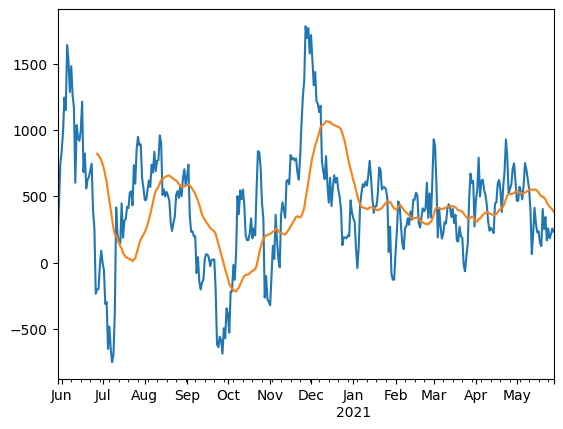

In [ ]:
# Define linear regression model to predict Close from previous time series features
lin_mdl = LinearRegression(fit_intercept=True)
y = df['Close'][:1577]
lin_mdl.fit(X[:1577], y)
lin_mdl_predictions = lin_mdl.predict(X[1577:])
df_deseason = df["Close"][1577+30:] - lin_mdl_predictions

ax = df_deseason.plot()
ax.plot(df_deseason.rolling(30).mean())

In [ ]:
mae = mean_absolute_error(df["Close"][1577+30:], lin_mdl_predictions)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(df["Close"][1577+30:], lin_mdl_predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 496.6086046027396
Root Mean Squared Error (RMSE): 597.6928974676281


<Axes: >

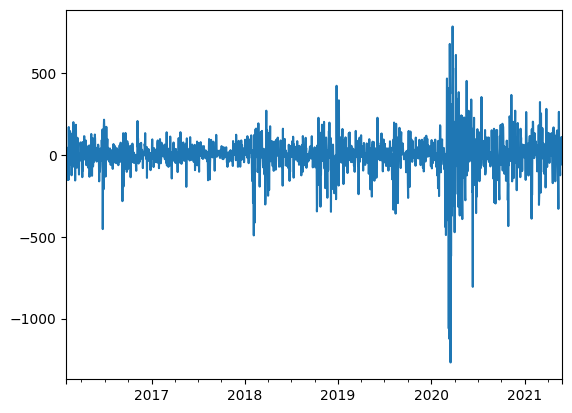

In [ ]:
df_deseason.plot()

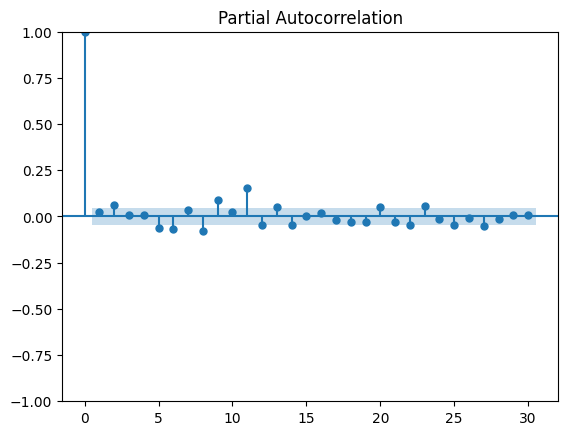

In [ ]:
# Plot partial autocorrelation
plot_pacf(df_deseason,lags=30)

y_pred = pd.Series(mdl.predict(X), index=X.index)

In [ ]:
df_deseason

,Close
2016-02-03,45.986622
2016-02-04,45.352694
2016-02-05,-146.268932
2016-02-06,-8.913373
2016-02-07,12.536936
...,...
2021-05-24,110.190564
2021-05-25,-57.684673
2021-05-26,50.771037
2021-05-27,89.295388


<Axes: >

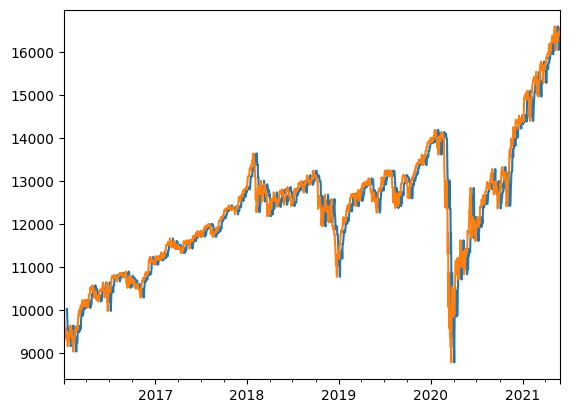

In [ ]:
lags = make_lags(df.Close,12)
lags['y_lag_12'].plot()
df.Close.plot()

In [ ]:
fig = make_subplots(rows=len(diffs), cols=1,subplot_titles=[f"Close_lag_{i}" for i in diffs])
for index,i in enumerate(diffs):
  fig.add_trace(go.Scatter(x=df.index, y=df[f'Close_lag_{i}'],text=f"Close_lag_{i}"),row=index+1,col= 1)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()

In [ ]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])
fig.show()

In [ ]:
df.Close

,Close
2016-01-04,10001.559570
2016-01-05,10028.059570
2016-01-06,9868.259766
2016-01-07,9650.419922
2016-01-08,9528.769531
...,...
2021-05-24,16464.689450
2021-05-25,16390.189450
2021-05-26,16451.960940
2021-05-27,16531.949220


# Model Implementation

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, Normalization, LayerNormalization, Conv1D, ReLU, Add, Input, Layer, Multiply, Dot, Concatenate, Reshape, Permute, Flatten
from tensorflow.keras import Model
from tensorflow import Tensor
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# lookback window, variable count

class EncoderBlock(Layer):

  def __init__(self, units, **kwargs):
    super(EncoderBlock, self).__init__(**kwargs)
    self.dense = Dense(units)
    self.layer_norm = LayerNormalization()
    self.relu = ReLU()

  def call(self, inputs):
    x = self.dense(inputs)
    x = self.layer_norm(x)
    x = self.relu(x)
    return x

class BetaLayer(Layer):

  def __init__(self,beta,**kwargs):
    super(BetaLayer, self).__init__(**kwargs)

    self.beta = beta

  def __call__(self, inputs):
    # inputs should be a list of two tensors
    if not isinstance(inputs, list) or len(inputs) != 2:
      raise Exception("Invalid input. Expected a list of two tensors.")

    return self.beta * inputs[0] + (1-self.beta) * inputs[1]

class Conv1Dwith1D(Layer):
    def __init__(self, ksize, axis, **kwargs):
      super(Conv1Dwith1D, self).__init__(**kwargs)
      self.ksize = ksize
      self.axis = axis
      # Instantiate the Conv1D layer here, in __init__
      self.conv1d_layer = Conv1D(filters = 1, kernel_size = self.ksize, padding = "same")

    def call(self, inputs):
      # x = tf.expand_dims(inputs,axis = self.axis)
      x = self.conv1d_layer(inputs) # Use the instantiated layer
      return x#tf.squeeze(x, axis = self.axis)

class Transpose(Layer):
  def __init__(self, perm, **kwargs):
    super(Transpose, self).__init__(**kwargs)
    self.perm = perm

  def call(self, inputs):
    return tf.transpose(inputs, perm = self.perm)


def model(observation_count, time_feature_count, beta, lookback_window=10, prediction_horizon=5):
  """
  observation_count : Number of features
  time_feature_count : Number of time dependent features
  beta : Ratio for the beta layer
  lookback_window: Number of time steps to look back
  prediction_horizon: Number of time steps to predict
  """
  # Encoder Decoder
  time_input = Input(shape=(lookback_window, time_feature_count), name='time_input')

  # Encoder Section: Encode the timestamp data
  # Pass the symbolic time_input tensor to the first EncoderBlock
  x = EncoderBlock(observation_count)(time_input)
  x = EncoderBlock(observation_count)(x)

  x = Conv1Dwith1D(ksize=3, axis=-1)(x)

  # Encoder output shape: lookback_window, observation_count
  encoder_output = Dense(observation_count, name = "encoder_output")(x)

  transpose = Transpose(perm = [0,2,1])
  # Decoder output shape: prediction_horizon, observation_count
  decoder = Dense(prediction_horizon, name = 'decoder')(transpose(encoder_output))
  decoder = transpose(decoder)

  # Bonster output shape: prediction_horizon, observation_count
  feature_input = Input(shape=(lookback_window, observation_count), name='feature_input')
  normalizer_layer = Normalization()
  # Pass the symbolic feature_input tensor to the normalizer_layer
  bonster_output = normalizer_layer(feature_input)

  transpose = Transpose(perm = [0,2,1])

  bonster_output = transpose(bonster_output)
  bonster_output = Dense(prediction_horizon)(bonster_output)
  bonster_output = transpose(bonster_output)


  # Add the two bonster and encoder_output layers using BetaLayer, then denormalize them
  beta_layer_output = BetaLayer(beta)([bonster_output, decoder])
  # Denormalize the output
  de_norm = Normalization(axis=-1, mean=normalizer_layer.mean, variance=normalizer_layer.variance, invert=True)(beta_layer_output)

  final_model = Model(inputs=[time_input, feature_input], outputs=de_norm)

  # Output should have shape prediction_horizon, observations
  return final_model

In [ ]:
observation_count = 1
time_feature_count = 3
beta = 0.5
lookback_window = 10
prediction_horizon = 5
mdl = model(observation_count, time_feature_count, beta, lookback_window, prediction_horizon)
print(mdl.inputs)
print(mdl.outputs)
mdl.summary()

[<KerasTensor shape=(None, 10, 3), dtype=float32, sparse=False, ragged=False, name=time_input>, <KerasTensor shape=(None, 10, 1), dtype=float32, sparse=False, ragged=False, name=feature_input>]
[<KerasTensor shape=(None, 5, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 10, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block       │ (None, 10, 1)     │          6 │ time_input[0][0]  │
│ (EncoderBlock)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 10, 1)     │          4 │ encoder_block[0]… │
│ (EncoderBlock)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_input       │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_dwith1d       │ (None, 10, 1)     │          4 │ encoder_block_1[… │
│ (Conv1Dwith1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 10, 1)     │          3 │ feature_input[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 10, 1)     │          2 │ conv1_dwith1d[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transpose_1         │ (None, 5, 1)      │          0 │ normalization[0]… │
│ (Transpose)         │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transpose           │ (None, 5, 1)      │          0 │ encoder_output[0… │
│ (Transpose)         │                   │            │ decoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 5)      │         55 │ transpose_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (Dense)     │ (None, 1, 5)      │         55 │ transpose[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 5, 1)      │          0 │ transpose_1[1][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 5, 1)      │          0 │ transpose[1][0]   │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5, 1)      │          0 │ multiply[0][0],   │
│                     │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 5, 1)      │          0 │ add[0][0]         │
│ (Normalization)     │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 129 (520.00 B)

 Trainable params: 126 (504.00 B)

 Non-trainable params: 3 (16.00 B)

Create Train and Test Dataset

In [ ]:
df.shape

(1972, 15)

In [ ]:
dataset = df[["day","month","year","Close"]]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_size = int(len(df)*0.8)
test_size = len(df) - train_size
print(train_size, test_size)

train_df = dataset[:1577]
test_df = dataset[1577:]

# Scale Close values so that model is more stable during training
train_df["Close_scaled"] = scaler.fit_transform(train_df[["Close"]].copy())
test_df["Close_scaled"] = scaler.transform(test_df[["Close"]].copy())




/tmp/ipykernel_194/2075739430.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_194/2075739430.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
trainX_time = np.array([train_df[i: i + lookback_window][["day","month","year"]] for i in range(train_size - (prediction_horizon + lookback_window))])
trainX_val = np.array([train_df[i: i + lookback_window]["Close_scaled"] for i in range(train_size - (prediction_horizon + lookback_window))])
trainY = np.array([train_df[i + lookback_window: i + lookback_window + prediction_horizon]["Close_scaled"] for i in range(train_size - (prediction_horizon + lookback_window))])

testX_time = np.array([test_df[i: i+lookback_window][["day","month","year"]] for i in range(len(test_df) - (prediction_horizon + lookback_window))])
testX_val = np.array([test_df[i: i+lookback_window]["Close_scaled"] for i in range(len(test_df) - (prediction_horizon + lookback_window))])
testY = np.array([test_df[i + lookback_window: i+lookback_window+prediction_horizon]["Close_scaled"] for i in range(len(test_df) - (prediction_horizon + lookback_window))])



In [ ]:
trainX_time.shape, trainX_val.shape, trainY.shape, testX_time.shape, testX_val.shape, testY.shape

((1562, 10, 3), (1562, 10), (1562, 5), (380, 10, 3), (380, 10), (380, 5))

Train model

In [ ]:
trainY

array([[0.13673594, 0.09660883, 0.09660883, 0.09660883, 0.09660883],
       [0.09660883, 0.09660883, 0.09660883, 0.09660883, 0.09699922],
       [0.09660883, 0.09660883, 0.09660883, 0.09699922, 0.0701947 ],
       ...,
       [0.35684881, 0.39423798, 0.39574009, 0.41446448, 0.41446448],
       [0.39423798, 0.39574009, 0.41446448, 0.41446448, 0.41446448],
       [0.39574009, 0.41446448, 0.41446448, 0.41446448, 0.46014477]])

Train Model

In [ ]:
mdl = model(observation_count, time_feature_count, beta, lookback_window, prediction_horizon)
mdl.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['precision','recall'])

mdl.fit([trainX_time,trainX_val],trainY, epochs=100, batch_size=16)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3593 - precision: 1.0000 - recall: 0.1854
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0681 - precision: 0.9995 - recall: 0.4906
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0235 - precision: 0.9995 - recall: 0.8077
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0202 - precision: 0.9997 - recall: 0.8259
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0177 - precision: 0.9997 - recall: 0.8156
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0154 - precision: 0.9997 - recall: 0.8023
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0134 - precision: 0.9998 - recall: 0.7886
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - precision: 0.9998 - recall: 0.7810
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0099 - precision: 0.9998 - recall: 0.7766
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - prec

Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predY = mdl.predict([testX_time,testX_val]).reshape((380,5))

# De-normalize predictions evaluation in original scale
predY_original_scale = scaler.inverse_transform(predY)
testY_original_scale = np.array([test_df[i + lookback_window: i+lookback_window+prediction_horizon]["Close"] for i in range(len(test_df) - (prediction_horizon + lookback_window))])


# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(testY_original_scale, predY_original_scale)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(testY_original_scale, predY_original_scale))
print(f"Root Mean Squared Error (RMSE): {rmse}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Mean Absolute Error (MAE): 185.2549310906251
Root Mean Squared Error (RMSE): 248.02443155664997


In [ ]:
predY_original_scale, testY_original_scale

(array([[11333.632, 11356.053, 11239.28 , 11211.159, 11332.647],
        [11349.112, 11317.511, 11236.914, 11283.442, 11306.64 ],
        [11341.798, 11319.135, 11344.459, 11306.432, 11322.15 ],
        ...,
        [16365.479, 16263.222, 16208.954, 16286.295, 16136.837],
        [16329.3  , 16219.714, 16228.8  , 16182.465, 16190.831],
        [16307.86 , 16257.82 , 16277.764, 16170.511, 16219.552]],
       dtype=float32),
 array([[11354.33984, 11354.33984, 11281.37012, 11055.58008, 10829.44043],
        [11354.33984, 11281.37012, 11055.58008, 10829.44043, 10927.41016],
        [11281.37012, 11055.58008, 10829.44043, 10927.41016, 10947.32031],
        ...,
        [16375.     , 16375.     , 16375.     , 16464.68945, 16390.18945],
        [16375.     , 16375.     , 16464.68945, 16390.18945, 16451.96094],
        [16375.     , 16464.68945, 16390.18945, 16451.96094, 16531.94922]]))